In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


LOAD DATASET

In [2]:
heart=pd.read_csv("heart_disease_cleveland.csv")
heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [3]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
heart.shape

(303, 14)

In [5]:
heart.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [6]:
heart.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


DATA PREPROCESSING

In [7]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [8]:
heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [9]:
#Find missing value
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [10]:
heart.duplicated().sum()

np.int64(0)

In [11]:
#Target distribution
heart["target"].value_counts()

,count
target,
0,164
1,139


In [12]:
# Fill missing values with median
heart["ca"]=heart["ca"].fillna(heart["ca"].median())
heart["thal"]=heart["thal"].fillna(heart["thal"].median())

In [13]:
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [14]:
heart.shape

(303, 14)

EDA

In [15]:
# Target distribution
print(heart["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


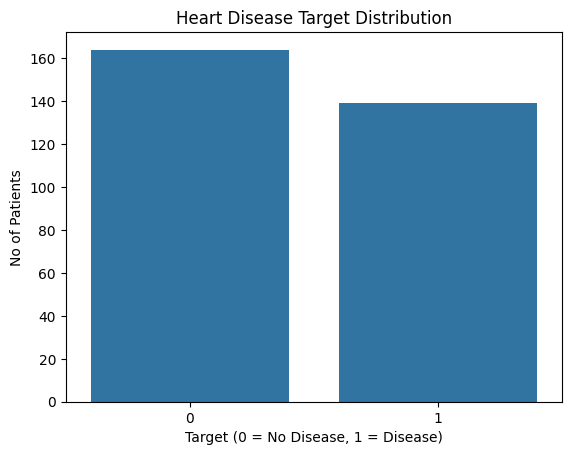

In [16]:
# Target distribution plot
sns.countplot(x="target",data=heart)
plt.title("Heart Disease Target Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("No of Patients")
plt.show()


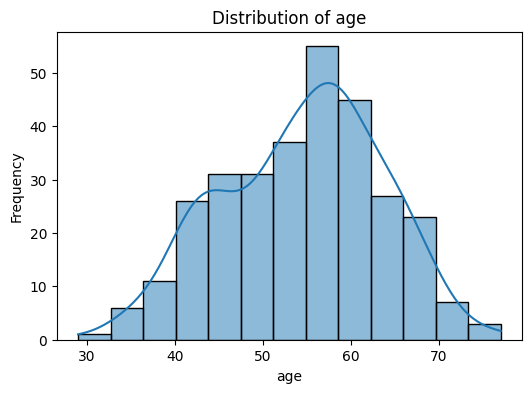

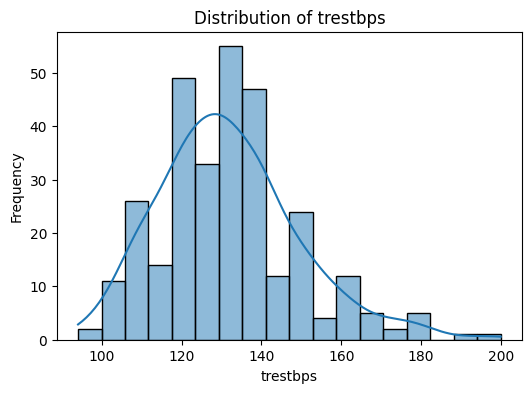

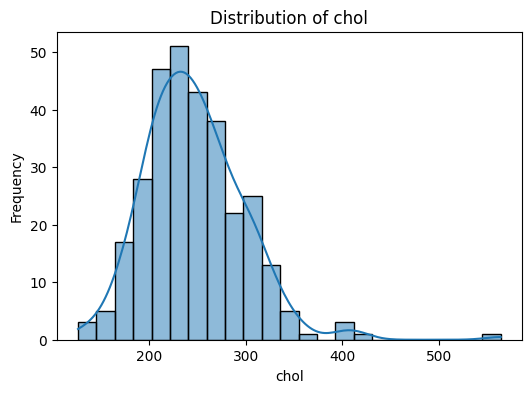

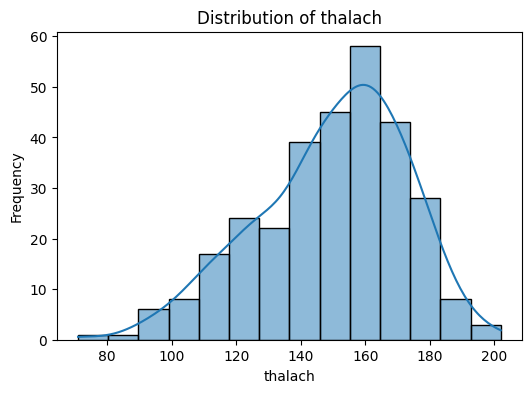

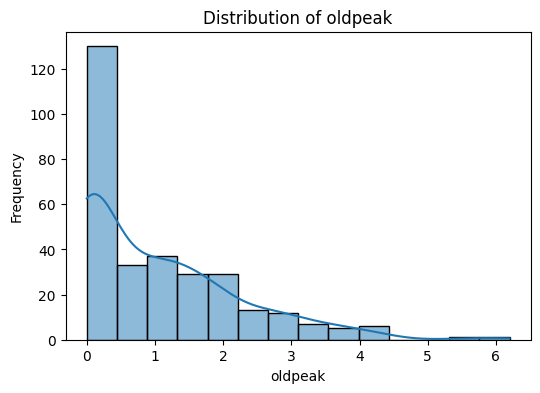

In [17]:
# Numerical feature distributions
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]
for feature in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=heart, x=feature, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()


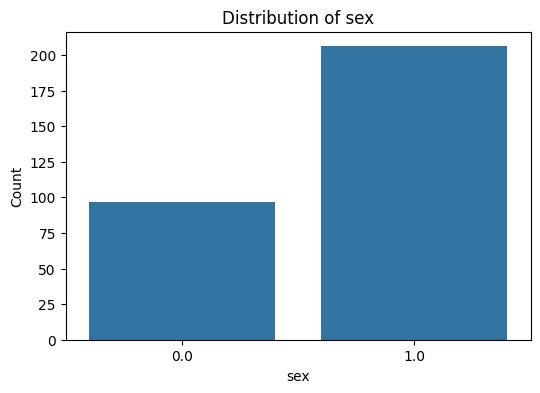

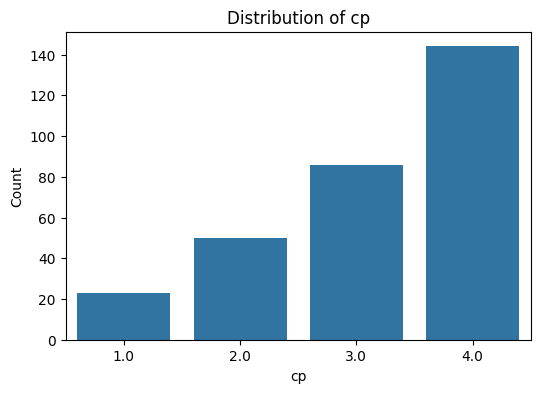

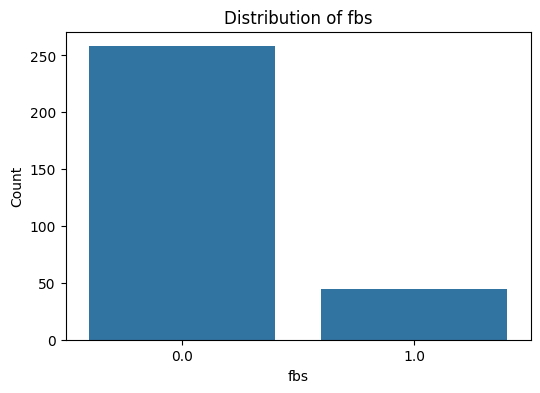

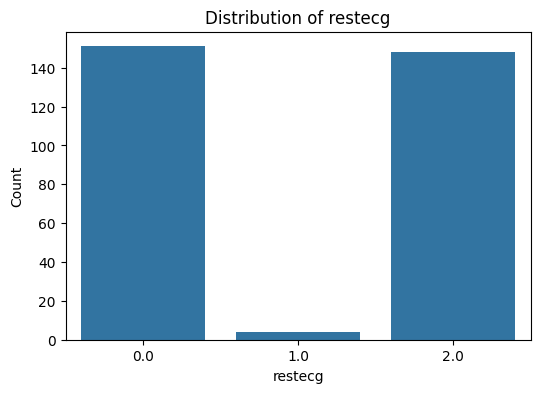

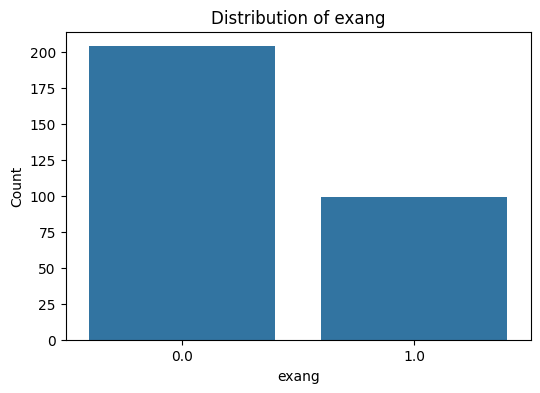

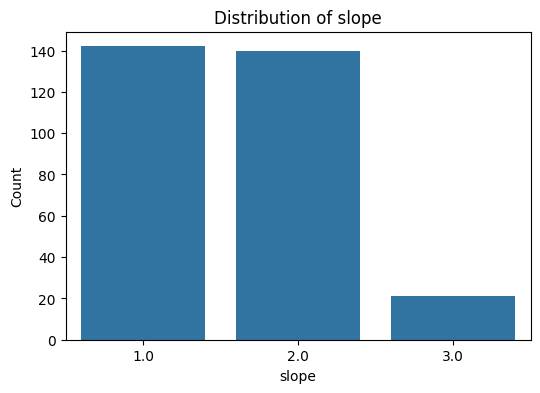

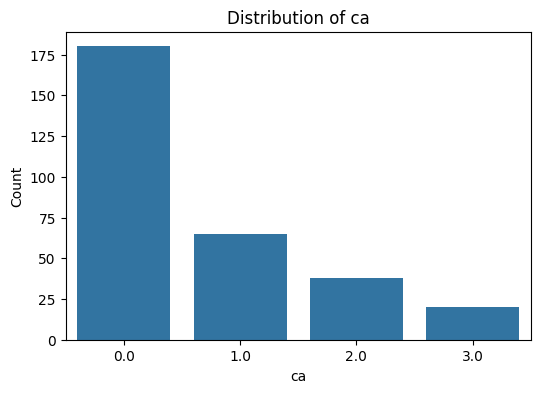

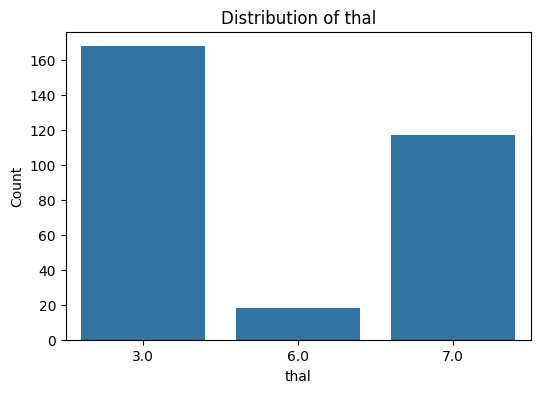

In [18]:
#Categorical/Binary Features Distribution
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

for feature in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=feature, data=heart)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

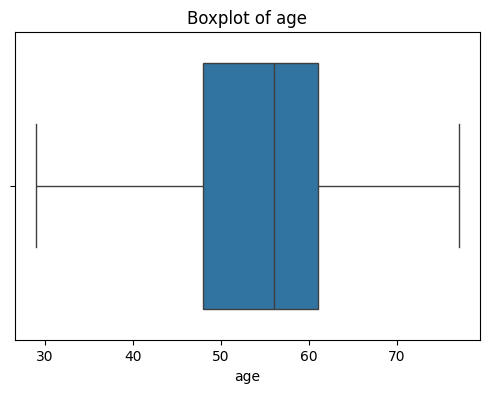

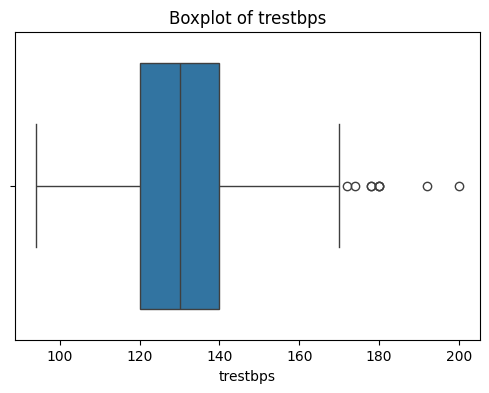

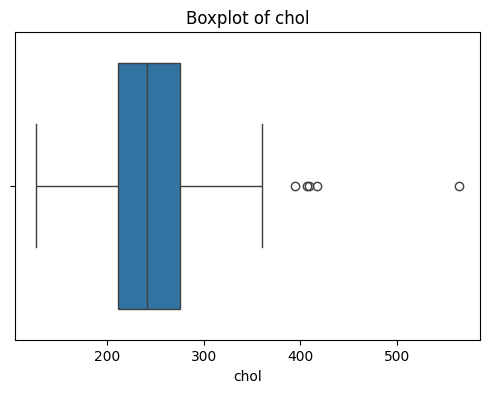

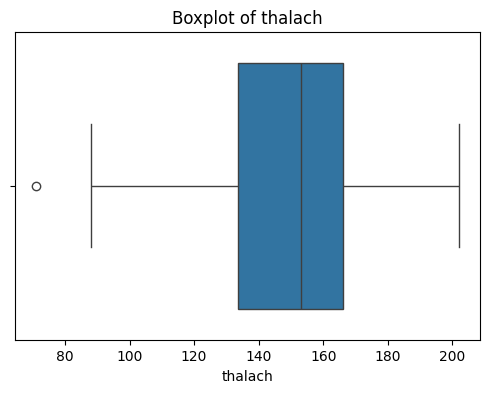

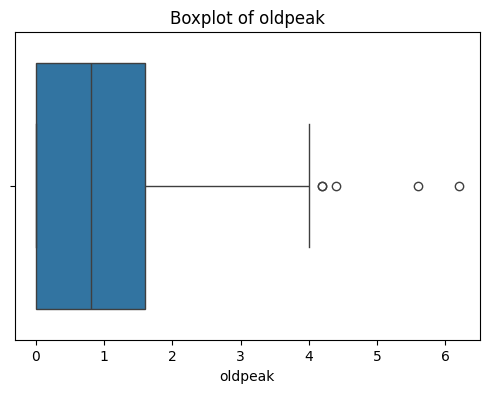

In [19]:
#Boxplot — Outlier Detection
for feature in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=heart[feature])
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.show()

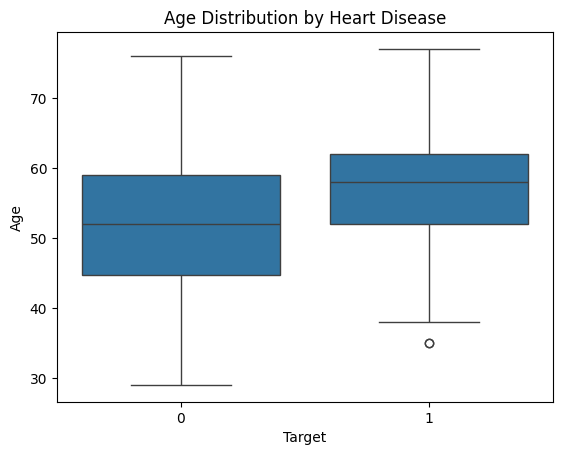

In [20]:
#Feature vs Target Analysis
#1.Age vs Heart Disease
sns.boxplot(x="target", y="age", data=heart)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Target")
plt.ylabel("Age")
plt.show()

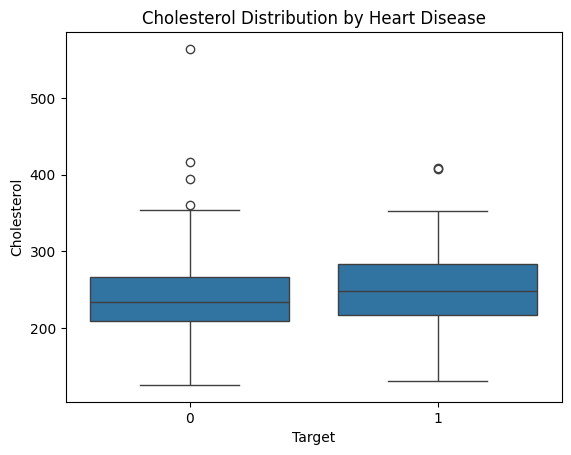

In [21]:
#2.Cholesterol vs Target
sns.boxplot(x="target", y="chol", data=heart)

plt.title("Cholesterol Distribution by Heart Disease")
plt.xlabel("Target")
plt.ylabel("Cholesterol")
plt.show()

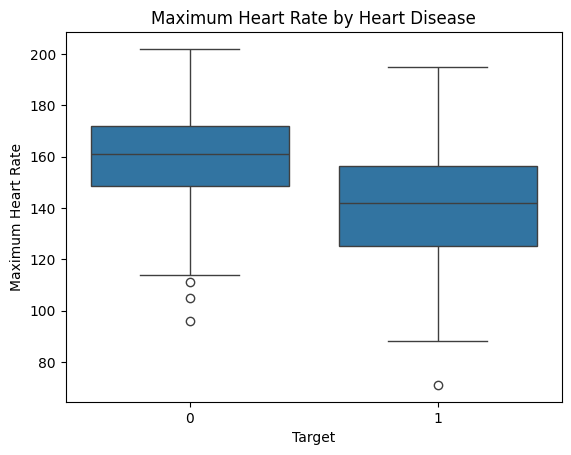

In [22]:
#3.Thalach vs Target
sns.boxplot(x="target", y="thalach", data=heart)

plt.title("Maximum Heart Rate by Heart Disease")
plt.xlabel("Target")
plt.ylabel("Maximum Heart Rate")
plt.show()

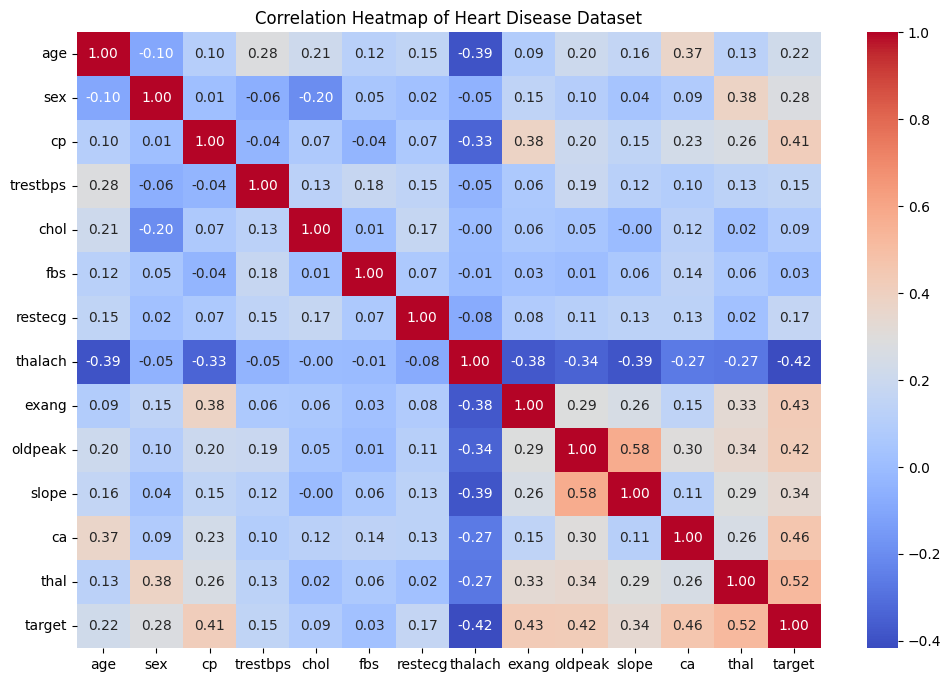

In [23]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

correlation = heart.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Heart Disease Dataset")
plt.show()

In [24]:
#Target ke Saath Correlation
target_correlation = heart.corr()["target"].sort_values(
    ascending=False
)

print(target_correlation)

target      1.000000
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


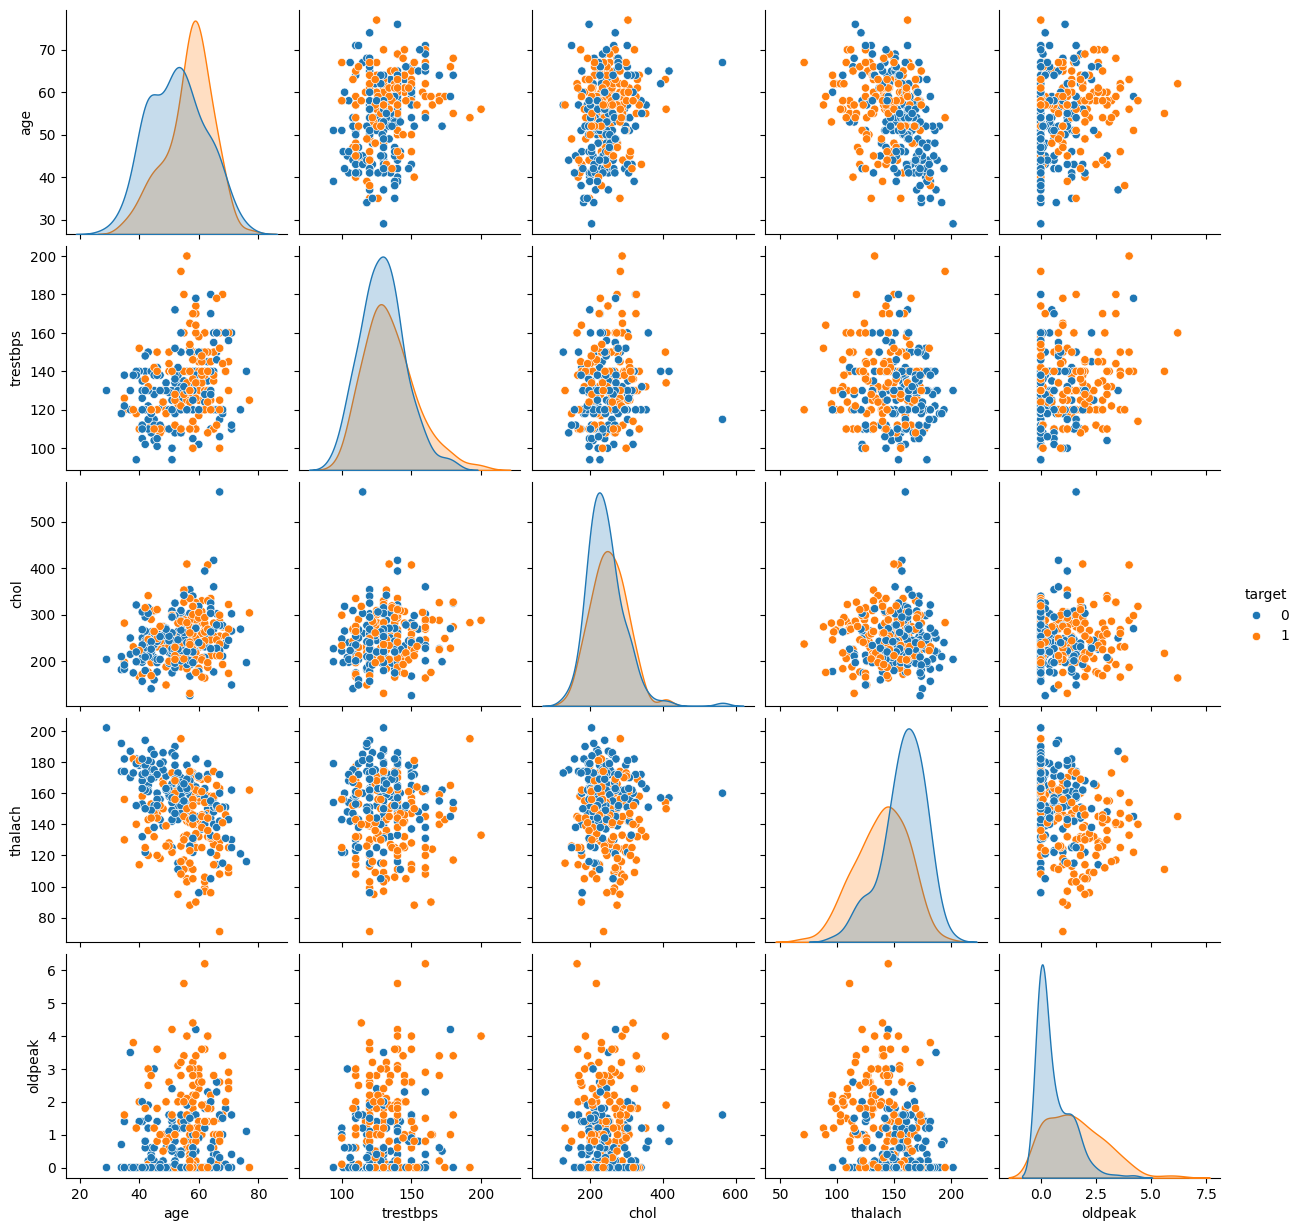

In [25]:
#Pairplot( for numerical features)
selected_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "target"
]

sns.pairplot(
    heart[selected_features],
    hue="target"
)

plt.show()

Feature Engineering & Encoding

In [26]:
# Separate input features and target

X = heart.drop("target", axis=1)
y = heart["target"]

In [27]:
y

,target
0,0
1,1
2,1
3,0
4,0
...,...
298,1
299,1
300,1
301,1


In [28]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303,)


In [29]:
#Check Unique Values
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

for feature in categorical_features:
    print(feature, ":", sorted(X[feature].unique()))

sex : [np.float64(0.0), np.float64(1.0)]
cp : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
fbs : [np.float64(0.0), np.float64(1.0)]
restecg : [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
exang : [np.float64(0.0), np.float64(1.0)]
slope : [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
ca : [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]
thal : [np.float64(3.0), np.float64(6.0), np.float64(7.0)]


In [30]:
#Feature Names Check
print("Input Features:")
print(X.columns.tolist())

Input Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [31]:
#Outlier Detection
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]
#IQR se Outliers Count
for feature in numerical_features:
    Q1 = heart[feature].quantile(0.25)
    Q3 = heart[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = heart[
        (heart[feature] < lower_bound) |
        (heart[feature] > upper_bound)
    ]

    print(feature)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Outliers:", len(outliers))
    print()

age
Lower Bound: 28.5
Upper Bound: 80.5
Outliers: 0

trestbps
Lower Bound: 90.0
Upper Bound: 170.0
Outliers: 9

chol
Lower Bound: 115.0
Upper Bound: 371.0
Outliers: 5

thalach
Lower Bound: 84.75
Upper Bound: 214.75
Outliers: 1

oldpeak
Lower Bound: -2.4000000000000004
Upper Bound: 4.0
Outliers: 5



In [32]:
for feature in numerical_features:
    Q1 = heart[feature].quantile(0.25)
    Q3 = heart[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (heart[feature] < lower_bound) |
        (heart[feature] > upper_bound)
    ).sum()

    percentage = (outlier_count / len(heart)) * 100

    print(f"{feature}: {outlier_count} outliers ({percentage:.2f}%)")

age: 0 outliers (0.00%)
trestbps: 9 outliers (2.97%)
chol: 5 outliers (1.65%)
thalach: 1 outliers (0.33%)
oldpeak: 5 outliers (1.65%)


In [33]:
for feature in numerical_features:
    Q1 = heart[feature].quantile(0.25)
    Q3 = heart[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = heart[
        (heart[feature] < lower_bound) |
        (heart[feature] > upper_bound)
    ]

    print(f"\n{feature} outlier values:")
    print(outliers[feature].values)


age outlier values:
[]

trestbps outlier values:
[172. 180. 200. 174. 178. 192. 180. 178. 180.]

chol outlier values:
[417. 407. 564. 394. 409.]

thalach outlier values:
[71.]

oldpeak outlier values:
[6.2 5.6 4.2 4.2 4.4]


TRAIN-TEST-SPLIT

In [34]:

# STEP 7.1 : SEPARATE FEATURES AND TARGET

X = heart.drop("target", axis=1)
y = heart["target"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (303, 13)
Target (y) shape: (303,)


In [35]:
print("First 5 rows of X:")
display(X.head())

print("\nFirst 5 values of y:")
display(y.head())

First 5 rows of X:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0



First 5 values of y:


,target
0,0
1,1
2,1
3,0
4,0


In [36]:
print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Target percentage:
target
0    54.125413
1    45.874587
Name: proportion, dtype: float64


In [37]:
#Train-Test Split


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [38]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (242, 13)
X_test shape : (61, 13)
y_train shape: (242,)
y_test shape : (61,)


In [39]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
target
0    131
1    111
Name: count, dtype: int64

Testing target distribution:
target
0    33
1    28
Name: count, dtype: int64


In [40]:
print("Training target percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target percentage:")
print(y_test.value_counts(normalize=True) * 100)

Training target percentage:
target
0    54.132231
1    45.867769
Name: proportion, dtype: float64

Testing target percentage:
target
0    54.098361
1    45.901639
Name: proportion, dtype: float64


In [41]:
print("Missing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum().sum())

Missing values in X_train:
0

Missing values in X_test:
0


ENCODING

In [42]:
categorical_features = [
    "cp",
    "restecg",
    "slope",
    "ca",
    "thal"
]
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [43]:
X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

In [44]:
X_test_cat = encoder.transform(
    X_test[categorical_features]
)

In [45]:
encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

print(encoded_feature_names)

['cp_1.0' 'cp_2.0' 'cp_3.0' 'cp_4.0' 'restecg_0.0' 'restecg_1.0'
 'restecg_2.0' 'slope_1.0' 'slope_2.0' 'slope_3.0' 'ca_0.0' 'ca_1.0'
 'ca_2.0' 'ca_3.0' 'thal_3.0' 'thal_6.0' 'thal_7.0']


In [46]:
print("Categorical features before encoding:",
      X_train[categorical_features].shape)

print("Categorical features after encoding:",
      X_train_cat.shape)

Categorical features before encoding: (242, 5)
Categorical features after encoding: (242, 17)


FEATURE SCALING

In [47]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

In [48]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [49]:
X_train_num = scaler.fit_transform(
    X_train[numerical_features]
)

In [50]:
X_test_num = scaler.transform(
    X_test[numerical_features]
)

In [51]:
print("Before Scaling:")
display(X_train[numerical_features].head())

print("\nAfter Scaling:")
display(
    pd.DataFrame(
        X_train_num,
        columns=numerical_features
    ).head()
)

Before Scaling:


,age,trestbps,chol,thalach,oldpeak
180,48.0,124.0,274.0,166.0,0.5
208,55.0,130.0,262.0,155.0,0.0
167,54.0,132.0,288.0,159.0,0.0
105,54.0,108.0,309.0,156.0,0.0
297,57.0,140.0,241.0,123.0,0.2



After Scaling:


,age,trestbps,chol,thalach,oldpeak
0,-0.615385,-0.3,0.448669,0.396825,-0.1875
1,-0.076923,0.0,0.266160,0.047619,-0.5000
2,-0.153846,0.1,0.661597,0.174603,-0.5000
3,-0.153846,-1.1,0.980989,0.079365,-0.5000
4,0.076923,0.5,-0.053232,-0.968254,-0.3750


In [52]:
print("Numerical data before scaling:",
      X_train[numerical_features].shape)

print("Numerical data after scaling:",
      X_train_num.shape)

Numerical data before scaling: (242, 5)
Numerical data after scaling: (242, 5)


In [53]:
#Final Processed Dataset
binary_features = [
    "sex",
    "fbs",
    "exang"
]
X_train_binary = X_train[binary_features].values
X_test_binary = X_test[binary_features].values

In [54]:
import numpy as np

X_train_processed = np.hstack([
    X_train_num,
    X_train_cat,
    X_train_binary
])

X_test_processed = np.hstack([
    X_test_num,
    X_test_cat,
    X_test_binary
])

In [55]:
print("Final X_train shape:",
      X_train_processed.shape)

print("Final X_test shape:",
      X_test_processed.shape)

print("y_train shape:",
      y_train.shape)

print("y_test shape:",
      y_test.shape)

Final X_train shape: (242, 25)
Final X_test shape: (61, 25)
y_train shape: (242,)
y_test shape: (61,)


In [56]:
print(
    "Missing values in X_train:",
    np.isnan(X_train_processed).sum()
)

print(
    "Missing values in X_test:",
    np.isnan(X_test_processed).sum()
)

Missing values in X_train: 0
Missing values in X_test: 0


In [57]:
print(
    "Infinite values in X_train:",
    np.isinf(X_train_processed).sum()
)

print(
    "Infinite values in X_test:",
    np.isinf(X_test_processed).sum()
)

Infinite values in X_train: 0
Infinite values in X_test: 0


MODEL TRAINING

In [58]:
# ==========================================
# STEP 10 : IMPORT ML MODELS
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

!pip install xgboost -q
from xgboost import XGBClassifier

In [59]:
# ==========================================
# CREATE MODELS
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    )
}

In [60]:
# ==========================================
# TRAIN ALL MODELS
# ==========================================

trained_models = {}

for name, model in models.items():

    model.fit(X_train_processed, y_train)

    trained_models[name] = model

    print(name, "trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
XGBoost trained successfully


In [61]:
# ==========================================
# MAKE PREDICTIONS
# ==========================================

predictions = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test_processed)

    predictions[name] = y_pred

    print(name)
    print(y_pred[:10])
    print()

Logistic Regression
[0 1 0 0 0 0 0 0 1 0]

Decision Tree
[1 1 0 0 0 0 1 0 1 0]

Random Forest
[0 1 0 0 0 0 0 0 1 0]

XGBoost
[0 1 0 0 0 0 1 0 1 0]



In [62]:
from sklearn.metrics import accuracy_score

accuracy_results = {}

for name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_results[name] = accuracy

    print(name, ":", round(accuracy, 4))

Logistic Regression : 0.8852
Decision Tree : 0.7541
Random Forest : 0.9016
XGBoost : 0.8689


In [63]:
for name, accuracy in accuracy_results.items():
    print(name, ":", round(accuracy * 100, 2), "%")

Logistic Regression : 88.52 %
Decision Tree : 75.41 %
Random Forest : 90.16 %
XGBoost : 86.89 %


In [64]:
results_df = pd.DataFrame({
    "Model": accuracy_results.keys(),
    "Accuracy": accuracy_results.values()
})

results_df["Accuracy (%)"] = results_df["Accuracy"] * 100

results_df

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.885246,88.524590
1,Decision Tree,0.754098,75.409836
2,Random Forest,0.901639,90.163934
3,XGBoost,0.868852,86.885246


Detailed Model Evaluation

In [65]:
#1.Logistic Regression Evaluation
# Logistic Regression model
lr_model = models["Logistic Regression"]
# Prediction on test data
y_pred_lr = lr_model.predict(X_test_processed)

print("Logistic Regression predictions generated.")
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",
      lr_accuracy * 100, "%")

from sklearn.metrics import precision_score

lr_precision = precision_score(y_test, y_pred_lr)

print("Logistic Regression Precision:",
      lr_precision)

Logistic Regression predictions generated.
Logistic Regression Accuracy: 88.52459016393442 %
Logistic Regression Precision: 0.8387096774193549


In [66]:
from sklearn.metrics import recall_score

lr_recall = recall_score(y_test, y_pred_lr)

print("Logistic Regression Recall/Sensitivity:",
      lr_recall)

Logistic Regression Recall/Sensitivity: 0.9285714285714286


In [67]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Logistic Regression Confusion Matrix:")
print(cm_lr)

Logistic Regression Confusion Matrix:
[[28  5]
 [ 2 26]]


In [68]:
tn, fp, fn, tp = cm_lr.ravel()

lr_specificity = tn / (tn + fp)

print("Logistic Regression Specificity:",
      lr_specificity)

Logistic Regression Specificity: 0.8484848484848485


In [69]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression F1-Score:",
      lr_f1)

Logistic Regression F1-Score: 0.8813559322033898


In [70]:
from sklearn.metrics import roc_auc_score

y_prob_lr = lr_model.predict_proba(
    X_test_processed
)[:, 1]

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print("Logistic Regression ROC-AUC:",
      lr_auc)

Logistic Regression ROC-AUC: 0.9664502164502164


In [71]:
print("======================================")
print("LOGISTIC REGRESSION - EVALUATION")
print("======================================")

print("Accuracy       :", round(lr_accuracy * 100, 2), "%")
print("Precision      :", round(lr_precision * 100, 2), "%")
print("Sensitivity    :", round(lr_recall * 100, 2), "%")
print("Specificity    :", round(lr_specificity * 100, 2), "%")
print("F1-Score       :", round(lr_f1 * 100, 2), "%")
print("ROC-AUC        :", round(lr_auc * 100, 2), "%")

LOGISTIC REGRESSION - EVALUATION
Accuracy       : 88.52 %
Precision      : 83.87 %
Sensitivity    : 92.86 %
Specificity    : 84.85 %
F1-Score       : 88.14 %
ROC-AUC        : 96.65 %


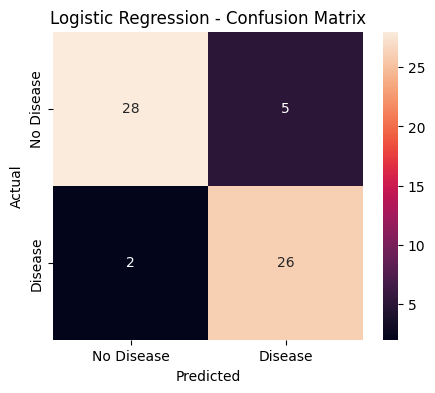

In [72]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [73]:
#2.Decision Tree Evaluation
dt_model = models["Decision Tree"]
y_pred_dt = dt_model.predict(X_test_processed)
print("Decision Tree predictions generated.")

from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:",
      round(dt_accuracy * 100, 2), "%")

from sklearn.metrics import precision_score
dt_precision = precision_score(y_test, y_pred_dt)
print("Decision Tree Precision:",
      round(dt_precision * 100, 2), "%")

from sklearn.metrics import recall_score
dt_recall = recall_score(y_test, y_pred_dt)
print("Decision Tree Sensitivity:",
      round(dt_recall * 100, 2), "%")

from sklearn.metrics import confusion_matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Decision Tree Confusion Matrix:")
print(cm_dt)



Decision Tree predictions generated.
Decision Tree Accuracy: 75.41 %
Decision Tree Precision: 68.57 %
Decision Tree Sensitivity: 85.71 %
Decision Tree Confusion Matrix:
[[22 11]
 [ 4 24]]


In [74]:
tn, fp, fn, tp = cm_dt.ravel()

dt_specificity = tn / (tn + fp)

print("Decision Tree Specificity:",
      round(dt_specificity * 100, 2), "%")

Decision Tree Specificity: 66.67 %


In [75]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree F1-Score:",
      round(dt_f1 * 100, 2), "%")

Decision Tree F1-Score: 76.19 %


In [76]:
from sklearn.metrics import roc_auc_score

y_prob_dt = dt_model.predict_proba(
    X_test_processed
)[:, 1]

dt_auc = roc_auc_score(
    y_test,
    y_prob_dt
)

print("Decision Tree ROC-AUC:",
      round(dt_auc * 100, 2), "%")

Decision Tree ROC-AUC: 76.19 %


In [77]:
print("======================================")
print("DECISION TREE - EVALUATION")
print("======================================")

print("Accuracy       :", round(dt_accuracy * 100, 2), "%")
print("Precision      :", round(dt_precision * 100, 2), "%")
print("Sensitivity    :", round(dt_recall * 100, 2), "%")
print("Specificity    :", round(dt_specificity * 100, 2), "%")
print("F1-Score       :", round(dt_f1 * 100, 2), "%")
print("ROC-AUC        :", round(dt_auc * 100, 2), "%")

DECISION TREE - EVALUATION
Accuracy       : 75.41 %
Precision      : 68.57 %
Sensitivity    : 85.71 %
Specificity    : 66.67 %
F1-Score       : 76.19 %
ROC-AUC        : 76.19 %


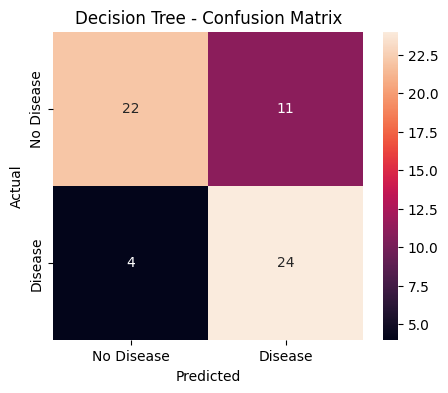

In [78]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [79]:
#3.Random Forest Evaluation
rf_model = models["Random Forest"]
y_pred_rf = rf_model.predict(X_test_processed)
print("Random Forest predictions generated.")

from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:",
      round(rf_accuracy * 100, 2), "%")

from sklearn.metrics import precision_score
rf_precision = precision_score(y_test, y_pred_rf)
print("Random Forest Precision:",
      round(rf_precision * 100, 2), "%")

from sklearn.metrics import recall_score
rf_recall = recall_score(y_test, y_pred_rf)
print("Random Forest Sensitivity:",
      round(rf_recall * 100, 2), "%")

from sklearn.metrics import confusion_matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest predictions generated.
Random Forest Accuracy: 90.16 %
Random Forest Precision: 84.38 %
Random Forest Sensitivity: 96.43 %
Random Forest Confusion Matrix:
[[28  5]
 [ 1 27]]


In [80]:
tn, fp, fn, tp = cm_rf.ravel()
rf_specificity = tn / (tn + fp)
print("Random Forest Specificity:",
      round(rf_specificity * 100, 2), "%")

Random Forest Specificity: 84.85 %


In [81]:
from sklearn.metrics import f1_score

rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest F1-Score:",
      round(rf_f1 * 100, 2), "%")

Random Forest F1-Score: 90.0 %


In [82]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(
    X_test_processed
)[:, 1]

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest ROC-AUC:",
      round(rf_auc * 100, 2), "%")

Random Forest ROC-AUC: 94.48 %


In [83]:
print("======================================")
print("RANDOM FOREST - EVALUATION")
print("======================================")

print("Accuracy       :", round(rf_accuracy * 100, 2), "%")
print("Precision      :", round(rf_precision * 100, 2), "%")
print("Sensitivity    :", round(rf_recall * 100, 2), "%")
print("Specificity    :", round(rf_specificity * 100, 2), "%")
print("F1-Score       :", round(rf_f1 * 100, 2), "%")
print("ROC-AUC        :", round(rf_auc * 100, 2), "%")

RANDOM FOREST - EVALUATION
Accuracy       : 90.16 %
Precision      : 84.38 %
Sensitivity    : 96.43 %
Specificity    : 84.85 %
F1-Score       : 90.0 %
ROC-AUC        : 94.48 %


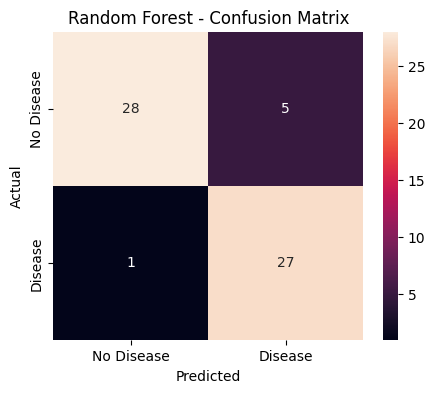

In [84]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [85]:
#4.XGBoost Evaluation
xgb_model = models["XGBoost"]
y_pred_xgb = xgb_model.predict(X_test_processed)
print("XGBoost predictions generated.")

from sklearn.metrics import accuracy_score
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(
    "XGBoost Accuracy:",
    round(xgb_accuracy * 100, 2),
    "%"
)

from sklearn.metrics import precision_score
xgb_precision = precision_score(y_test, y_pred_xgb)
print(
    "XGBoost Precision:",
    round(xgb_precision * 100, 2),
    "%"
)

from sklearn.metrics import recall_score
xgb_recall = recall_score(y_test, y_pred_xgb)
print(
    "XGBoost Sensitivity:",
    round(xgb_recall * 100, 2),
    "%"
)

from sklearn.metrics import confusion_matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost Confusion Matrix:")
print(cm_xgb)

XGBoost predictions generated.
XGBoost Accuracy: 86.89 %
XGBoost Precision: 81.25 %
XGBoost Sensitivity: 92.86 %
XGBoost Confusion Matrix:
[[27  6]
 [ 2 26]]


In [86]:
tn, fp, fn, tp = cm_xgb.ravel()

xgb_specificity = tn / (tn + fp)

print(
    "XGBoost Specificity:",
    round(xgb_specificity * 100, 2),
    "%"
)

XGBoost Specificity: 81.82 %


In [87]:
from sklearn.metrics import f1_score

xgb_f1 = f1_score(y_test, y_pred_xgb)

print(
    "XGBoost F1-Score:",
    round(xgb_f1 * 100, 2),
    "%"
)

XGBoost F1-Score: 86.67 %


In [88]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(
    "XGBoost ROC-AUC:",
    round(xgb_auc * 100, 2),
    "%"
)

XGBoost ROC-AUC: 94.7 %


In [89]:
print("======================================")
print("XGBOOST - EVALUATION")
print("======================================")

print("Accuracy       :", round(xgb_accuracy * 100, 2), "%")
print("Precision      :", round(xgb_precision * 100, 2), "%")
print("Sensitivity    :", round(xgb_recall * 100, 2), "%")
print("Specificity    :", round(xgb_specificity * 100, 2), "%")
print("F1-Score       :", round(xgb_f1 * 100, 2), "%")
print("ROC-AUC        :", round(xgb_auc * 100, 2), "%")

XGBOOST - EVALUATION
Accuracy       : 86.89 %
Precision      : 81.25 %
Sensitivity    : 92.86 %
Specificity    : 81.82 %
F1-Score       : 86.67 %
ROC-AUC        : 94.7 %


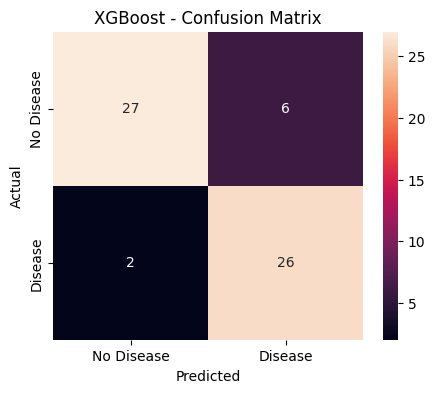

In [90]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")

plt.show()